In [1]:
import pandas as pd

df = pd.read_parquet('final_data.parquet')

In [2]:


# 1. Define your Targets (All relevant appliances for Lebanon)
# This creates a Multi-Output model target
target_cols = [
    'elec_ceiling_fan_kwh', 'elec_clothes_washer_kwh', 'elec_cooling_kwh',
    'elec_freezer_kwh', 'elec_heating_kwh',
    'elec_hot_water_kwh', 'elec_lighting_interior_kwh', 'elec_lighting_exterior_kwh',
    'elec_plug_loads_kwh', 'elec_range_oven_kwh', 'elec_refrigerator_kwh',
    'elec_television_kwh',  # Included as it's part of production/usage
]

# 2. Define your Features (The drivers of usage)
feature_cols = [
    'sqft', 'bedrooms', 'hvac_cooling_type', 
    'weather_drybulb_temp_c', 'weather_relative_humidity_pct', 
    'weather_wind_speed_m_s', 'weather_wind_direction_deg',
    'weather_global_horizontal_radiation_w_m2', 
    'weather_direct_normal_radiation_w_m2', 'weather_diffuse_horizontal_radiation_w_m2',
    'hour', 'month', 'day_of_week', 'is_weekend'
]

In [3]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Targets (y)
# We STILL drop the building_id from X so the model doesn't rely on a random ID number
X = df.drop(columns=target_cols + ['building_id'])
y = df[target_cols]

# 2. Standard Random Split
# This will mix hours from the same buildings into both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Clean and Cast (To prevent MemoryError and Type errors)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype('float32')
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

print(f"Random split complete: {len(X_train)} training rows, {len(X_test)} testing rows.")

Random split complete: 1401600 training rows, 350400 testing rows.


In [4]:
X_train

,sqft,weather_drybulb_temp_c,weather_relative_humidity_pct,weather_wind_speed_m_s,weather_wind_direction_deg,weather_global_horizontal_radiation_w_m2,weather_direct_normal_radiation_w_m2,weather_diffuse_horizontal_radiation_w_m2,hvac_cooling_type,bedrooms,hour,month,day_of_week,is_weekend
6382427,1698.000000,12.300000,22.889999,4.63,270.000000,650.0,959.0,83.0,0.0,2.0,15.0,2.0,4.0,0.0
2973935,1207.000122,12.000000,43.680000,0.00,0.000000,417.0,408.5,200.5,0.0,3.0,12.0,11.0,3.0,0.0
156199,3310.000244,5.670000,69.000000,1.20,83.330002,0.0,0.0,0.0,0.0,4.0,2.0,6.0,6.0,1.0
3254459,1228.000000,23.299999,17.790001,3.60,260.000000,406.0,746.5,88.5,0.0,3.0,15.0,11.0,5.0,1.0
6881091,854.000000,15.000000,80.629997,0.00,0.000000,0.0,0.0,0.0,0.0,2.0,1.0,5.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036715,1228.000000,5.670000,25.000000,0.00,0.000000,0.0,0.0,0.0,0.0,4.0,3.0,8.0,4.0,0.0
5657659,2179.000000,14.800000,82.790001,2.06,290.000000,0.0,0.0,0.0,0.0,1.0,23.0,6.0,0.0,0.0
527731,1698.000000,-3.890000,44.000000,0.00,0.000000,0.0,0.0,0.0,0.0,2.0,5.0,1.0,1.0,0.0
2684623,1698.000000,22.200001,78.570000,0.00,0.000000,0.0,0.0,0.0,0.0,1.0,20.0,8.0,0.0,0.0


In [5]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

train_encoded = encoder.fit_transform(X_train[['hvac_cooling_type']])
test_encoded = encoder.transform(X_test[['hvac_cooling_type']])

cols = encoder.get_feature_names_out(['hvac_cooling_type'])

train_encoded_df = pd.DataFrame(train_encoded, columns=cols, index=X_train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=cols, index=X_test.index)

X_train = X_train.drop('hvac_cooling_type', axis=1).join(train_encoded_df)
X_test = X_test.drop('hvac_cooling_type', axis=1).join(test_encoded_df)

X_train['bedrooms'] = pd.to_numeric(X_train['bedrooms'], errors='coerce')
X_test['bedrooms'] = pd.to_numeric(X_test['bedrooms'], errors='coerce')

In [31]:
import xgboost as xgb

model = xgb.XGBRegressor(
    tree_method='hist',
    device='cuda',
    n_estimators=300,
    max_depth=10,
    learning_rate=0.1,
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
y_pred = model.predict(X_test)

In [33]:
# If shape is (n_rows, 12) — multi-output, one column per appliance
pred_df = pd.DataFrame(y_pred, columns=target_cols)

# Save
pred_df.to_parquet("output.parquet")

In [34]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate global metrics
overall_r2 = r2_score(y_test, y_pred)
overall_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Overall R2 Score: {overall_r2:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f} kWh")

Overall R2 Score: 0.4751
Overall RMSE: 0.0356 kWh


In [35]:
# Create a list to store results
metrics_list = []

for i, col_name in enumerate(y_test.columns):
    # Extract true values and predictions for this specific appliance
    true_val = y_test.iloc[:, i]
    pred_val = y_pred[:, i]
    
    # Calculate metrics
    r2 = r2_score(true_val, pred_val)
    rmse = np.sqrt(mean_squared_error(true_val, pred_val))
    
    metrics_list.append({
        'Appliance': col_name,
        'R2 Score': round(r2, 4),
        'RMSE (kWh)': round(rmse, 4)
    })

# Convert to DataFrame for easy viewing
performance_df = pd.DataFrame(metrics_list).sort_values(by='R2 Score', ascending=False)
print(performance_df)

                     Appliance  R2 Score  RMSE (kWh)
8          elec_plug_loads_kwh    0.7530      0.0190
2             elec_cooling_kwh    0.7120      0.0569
11         elec_television_kwh    0.6828      0.0168
10       elec_refrigerator_kwh    0.6825      0.0071
3             elec_freezer_kwh    0.6088      0.0070
7   elec_lighting_exterior_kwh    0.6055      0.0013
6   elec_lighting_interior_kwh    0.5757      0.0218
0         elec_ceiling_fan_kwh    0.5667      0.0011
4             elec_heating_kwh    0.4771      0.0723
5           elec_hot_water_kwh    0.0910      0.0643
9          elec_range_oven_kwh   -0.0046      0.0368
1      elec_clothes_washer_kwh   -0.0518      0.0074


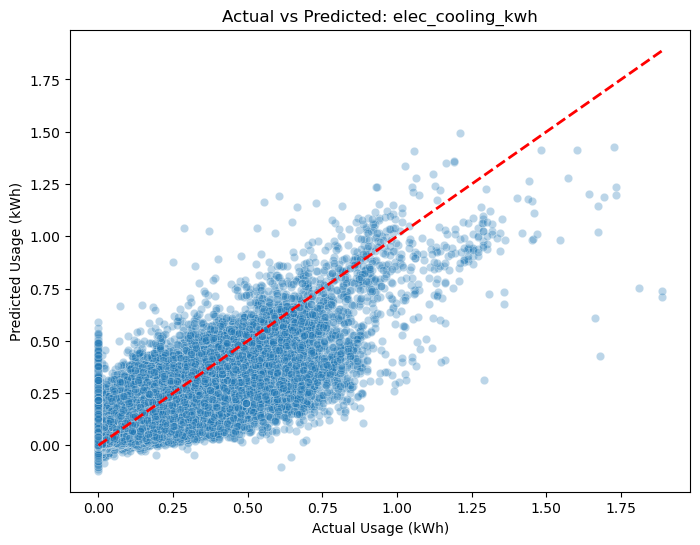

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_df = pd.DataFrame(y_pred, columns=y_test.columns, index=y_test.index)

# Pick a high-impact appliance to visualize, like Cooling
target_appliance = 'elec_cooling_kwh'

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test[target_appliance], y=y_pred_df[target_appliance], alpha=0.3)
plt.plot([y_test[target_appliance].min(), y_test[target_appliance].max()], 
         [y_test[target_appliance].min(), y_test[target_appliance].max()], 
         '--r', linewidth=2) # 45-degree line
plt.title(f'Actual vs Predicted: {target_appliance}')
plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.show()

In [37]:
model.save_model('usage_prediction.json')